# Лабораторная работа №1: численное дифференцирование и методы первого порядка

Цель: проверить численные градиенты, `Dual`-autograd и методы первого порядка на
Розенброке. Сравниваем точность, скорость, сходимость в 2D/ND и эталон `scipy`

## 1. Подготовка окружения

Импорт, seed и единый стиль графиков

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import optlib
from optlib import functions, experiments, plotting

np.random.seed(7)
plotting.use_notebook_style()
pd.set_option("display.float_format", lambda v: f"{v:.6g}")

print("optlib version:", getattr(optlib, "__version__", "n/a"))
print("целевые функции:", functions.list_objectives())

optlib version: 1.0.0
целевые функции: ['rosenbrock', 'rastrigin', 'himmelblau', 'ackley', 'beale', 'booth', 'styblinski_tang', 'desmos', 'desmos_surface']


## 2. Точность численного дифференцирования и выбор шага $h$

Три схемы конечных разностей:

| Схема | Формула | Порядок |
|-------|---------|---------|
| **Forward** | $\dfrac{f(x+h)-f(x)}{h}$ | $O(h)$ |
| **Central** | $\dfrac{f(x+h)-f(x-h)}{2h}$ | $O(h^2)$ |
| **Five-point** | $\dfrac{-f(x+2h)+8f(x+h)-8f(x-h)+f(x-2h)}{12h}$ | $O(h^4)$ |

Ищем оптимальный $h^*$: при большом шаге доминирует усечение, при малом
округление. `Dual`-autograd добавлен как эталон без подбора шага

In [2]:
# Точка вдали от минимума, где градиент Розенброка нетривиален.
probe = np.array([0.5, 1.5])
analytic = optlib.RosenbrockGradient(probe)
autograd = optlib.RosenbrockAutogradGradient(probe)

print("аналитический градиент:", analytic)
print("autograd (Dual):       ", autograd)
print("ошибка autograd:        %.2e" % np.linalg.norm(autograd - analytic))

steps = np.logspace(-12, -1, 60)
schemes = ["forward", "central", "five_point"]
errors = {s: np.empty_like(steps) for s in schemes}
for scheme in schemes:
    for i, h in enumerate(steps):
        grad = optlib.RosenbrockNumericalGradient(probe, scheme=scheme, step=h)
        errors[scheme][i] = np.linalg.norm(grad - analytic)

# Сводка: лучший достигнутый h по каждой схеме.
summary = pd.DataFrame(
    {
        "схема": schemes,
        "мин. ошибка": [errors[s].min() for s in schemes],
        "оптимальный h": [steps[np.argmin(errors[s])] for s in schemes],
        "порядок (теор.)": [1, 2, 4],
    }
)
summary

аналитический градиент: [-251.  250.]
autograd (Dual):        [-251.  250.]
ошибка autograd:        0.00e+00


,схема,мин. ошибка,оптимальный h,порядок (теор.)
0,forward,1.74015e-06,8.22724e-09,1
1,central,5.25564e-09,9.24915e-07,2
2,five_point,2.69632e-13,0.0423759,4


findfont: Failed to find font weight semibold, now using 700.


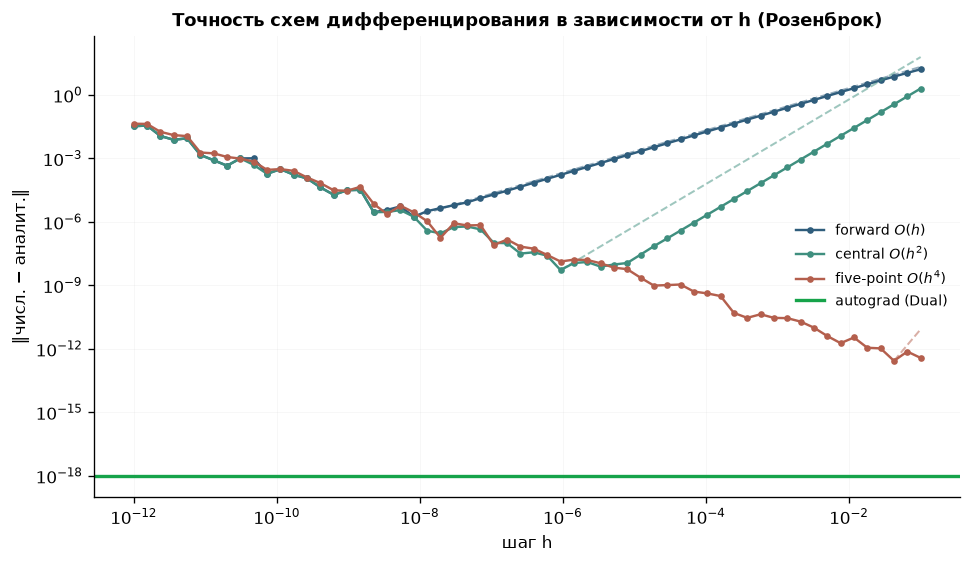

In [3]:
fig, ax = plt.subplots(figsize=(8.2, 4.8))
slopes = {"forward": 1, "central": 2, "five_point": 4}
labels = {
    "forward": "forward $O(h)$",
    "central": "central $O(h^2)$",
    "five_point": "five-point $O(h^4)$",
}
for idx, scheme in enumerate(schemes):
    color = plotting.PALETTE[idx]
    ax.loglog(steps, errors[scheme], "o-", ms=3, color=color, label=labels[scheme])
    # Опорная прямая теоретического наклона, привязанная к участку усечения.
    anchor = errors[scheme].argmin()
    h0, e0 = steps[anchor], errors[scheme][anchor]
    ref = e0 * (steps / h0) ** slopes[scheme]
    band = steps >= h0
    ax.loglog(steps[band], ref[band], "--", color=color, alpha=0.5, lw=1.2)

ax.axhline(
    np.linalg.norm(autograd - analytic) + 1e-18,
    color="#16a34a",
    lw=2,
    label="autograd (Dual)",
)
ax.set_xlabel("шаг h")
ax.set_ylabel("‖числ. − аналит.‖")
ax.set_title("Точность схем дифференцирования в зависимости от h (Розенброк)")
ax.legend()
plt.show()

**Вывод.** Порядки совпадают с теорией: five-point точнее forward на несколько
порядков. При слишком малом $h$ ошибка снова растёт. `Dual` даёт машинную
точность без выбора шага

## 3. Методы первого порядка на Розенброке 2D

Розенброк: $f(x,y)=100(y-x^2)^2+(1-x)^2$, минимум $(1,1)$, старт
$x_0=(-1.2,1.0)$. Сравниваем GD, Heavy Ball, Nesterov и Adam

In [4]:
rosen2d = functions.get_objective("rosenbrock", dimension=2)
x0 = np.array([-1.2, 1.0])

first_order_specs = {
    "gradient_descent": dict(learning_rate=1e-3, max_iter=20000),
    "heavy_ball": dict(learning_rate=1e-3, max_iter=20000, momentum=0.9),
    "nesterov": dict(learning_rate=1e-3, max_iter=20000, momentum=0.9),
    "adam": dict(learning_rate=1e-2, max_iter=20000),
}

first_results = {
    name: experiments.run_method(rosen2d, x0, name, gradient_tolerance=1e-6, **spec)
    for name, spec in first_order_specs.items()
}

rows = [experiments.result_summary(name, res, rosen2d) for name, res in first_results.items()]
table = pd.DataFrame(rows)[
    [
        "method",
        "value",
        "gradient_norm",
        "iterations",
        "function_evaluations",
        "converged",
        "distance_to_minimum",
    ]
]
table.columns = ["метод", "f*", "‖∇f‖", "итераций", "вызовов f", "сошёлся", "‖x*−x_min‖"]
table.round(8)

,метод,f*,‖∇f‖,итераций,вызовов f,сошёлся,‖x*−x_min‖
0,gradient_descent,2e-08,0.00012445,20000,20001,False,0.00031156
1,heavy_ball,0,9.75e-06,2472,2473,True,2.441e-05
2,nesterov,0,9.77e-06,2516,2517,True,2.446e-05
3,adam,0,8.48e-06,5147,5148,True,1.954e-05


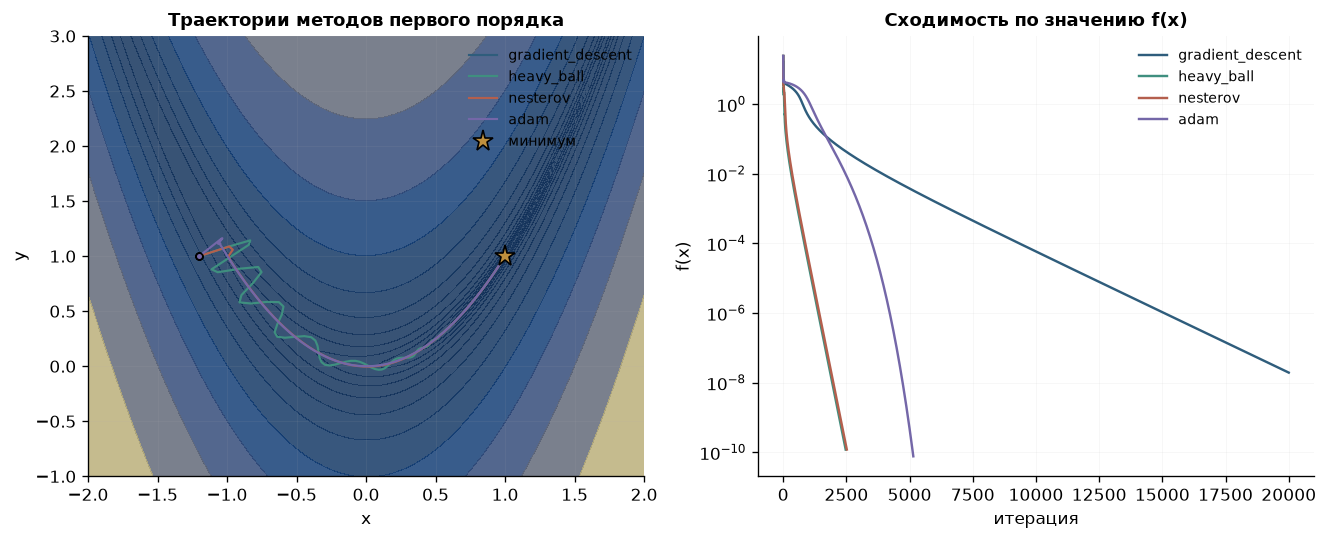

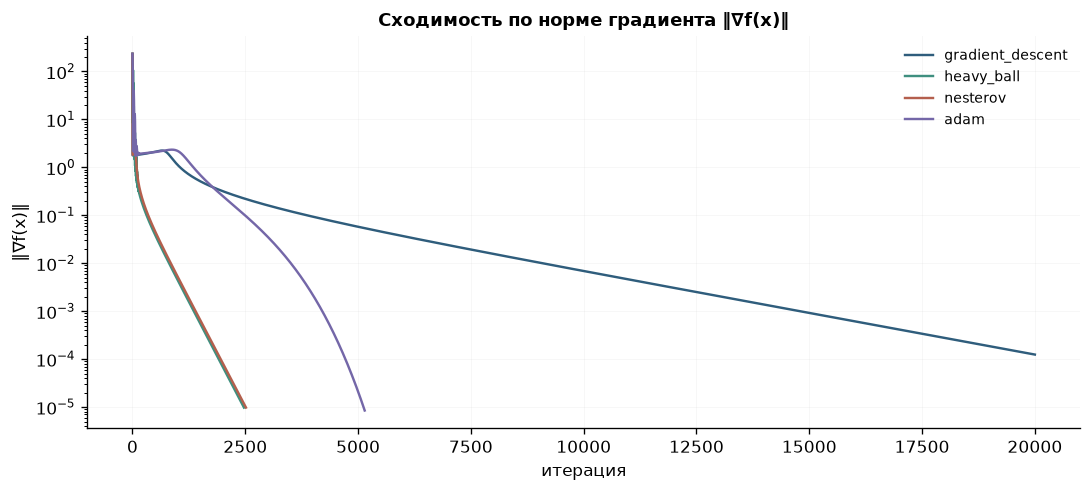

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))
plotting.plot_trajectories(
    axes[0],
    rosen2d.value,
    first_results,
    x_limits=(-2.0, 2.0),
    y_limits=(-1.0, 3.0),
    minimum=[1.0, 1.0],
    title="Траектории методов первого порядка",
)
plotting.plot_convergence(
    axes[1],
    first_results,
    key="f",
    title="Сходимость по значению f(x)",
)
plt.show()

fig, ax = plt.subplots(figsize=(9.2, 4.2))
plotting.plot_convergence(
    ax,
    first_results,
    key="grad_norm",
    title="Сходимость по норме градиента ‖∇f(x)‖",
)
plt.show()

**Вывод.** GD медленнее всех. Моментные методы и Adam быстрее проходят овраг;
осцилляции видны на графике нормы градиента

## 4. Многомерный Розенброк ($n = 2, 5, 10, 50, 100$)

Проверяем ND-форму:
$f(x)=\sum_{i=1}^{n-1}\left[100(x_{i+1}-x_i^2)^2+(1-x_i)^2\right]$
Минимум: $(1,\ldots,1)$; старт: чередование `-1.2/1.0`

In [6]:
def make_start(n: int) -> np.ndarray:
    x = np.full(n, -1.2)
    x[1::2] = 1.0
    return x


# В многомерном овраге Nesterov склонен «перелетать» долину, поэтому здесь
# берём чуть меньший шаг (5e-4), это сохраняет устойчивость при росте n.
nd_specs = {
    "gradient_descent": dict(learning_rate=1e-3, max_iter=30000),
    "heavy_ball": dict(learning_rate=1e-3, max_iter=30000, momentum=0.9),
    "nesterov": dict(learning_rate=5e-4, max_iter=30000, momentum=0.9),
    "adam": dict(learning_rate=1e-2, max_iter=30000),
}

nd_rows = []
for n in (2, 5, 10, 50, 100):
    obj = functions.get_objective("rosenbrock", dimension=n)
    start = make_start(n)
    for method, spec in nd_specs.items():
        res = experiments.run_method(obj, start, method, gradient_tolerance=1e-6, **spec)
        nd_rows.append(
            {
                "n": n,
                "метод": method,
                "f*": res["value"],
                "итераций": res["iterations"],
                "‖∇f‖": res["gradient_norm"],
                "сошёлся": res["converged"],
            }
        )

nd_table = pd.DataFrame(nd_rows)
pivot = nd_table.pivot(index="метод", columns="n", values="итераций")
print("Число итераций до останова (строки: метод, столбцы: размерность n):")
display(pivot)
nd_table.round(8)

Число итераций до останова (строки: метод, столбцы: размерность n):


n,2,5,10,50,100
метод,,,,,
adam,5147,9210,7708,8884,9744
gradient_descent,23430,19783,20579,27384,30000
heavy_ball,2472,2090,2276,2910,3769
nesterov,4991,4072,4233,5602,7314


,n,метод,f*,итераций,‖∇f‖,сошёлся
0,2,gradient_descent,0,23430,3.161e-05,True
1,2,heavy_ball,0,2472,9.75e-06,True
2,2,nesterov,0,4991,1.398e-05,True
3,2,adam,0,5147,8.48e-06,True
4,5,gradient_descent,0,19783,3.16e-05,True
5,5,heavy_ball,0,2090,9.71e-06,True
6,5,nesterov,0,4072,1.394e-05,True
7,5,adam,0,9210,9.44e-06,True
8,10,gradient_descent,0,20579,3.16e-05,True
9,10,heavy_ball,0,2276,9.67e-06,True


**Вывод.** При росте $n$ итераций становится больше. Adam и моментные методы
сохраняют сходимость до $n=100$; ND-градиент работает корректно

## 5. Автоматическое дифференцирование vs численное: точность и скорость

Сравниваем источники градиента: ошибка относительно аналитики и среднее время
одного вызова. Для численных схем шаг выбирается автоматически

In [7]:
import timeit

sample = np.random.uniform(-2.0, 2.0, size=(200, 2))
analytic_grads = np.array([optlib.RosenbrockGradient(p) for p in sample])


def mean_error(fn) -> float:
    errs = [np.linalg.norm(fn(p) - a) for p, a in zip(sample, analytic_grads)]
    return float(np.mean(errs))


def timed(fn, repeat: int = 2000) -> float:
    p = sample[0]
    t = timeit.timeit(lambda: fn(p), number=repeat)
    return t / repeat * 1e6  # микросекунды на вызов


sources = {
    "forward": lambda p: optlib.RosenbrockNumericalGradient(p, scheme="forward"),
    "central": lambda p: optlib.RosenbrockNumericalGradient(p, scheme="central"),
    "five_point": lambda p: optlib.RosenbrockNumericalGradient(p, scheme="five_point"),
    "autograd": optlib.RosenbrockAutogradGradient,
    "analytic": optlib.RosenbrockGradient,
}

diff_rows = []
for name, fn in sources.items():
    diff_rows.append(
        {
            "источник": name,
            "ср. ошибка": mean_error(fn),
            "мкс/вызов": timed(fn),
        }
    )
diff_table = pd.DataFrame(diff_rows)
diff_table

,источник,ср. ошибка,мкс/вызов
0,forward,2.15488e-05,2.51845
1,central,3.49574e-08,3.0292
2,five_point,1.00969e-10,3.3199
3,autograd,3.08731e-14,3.74375
4,analytic,0,3.388


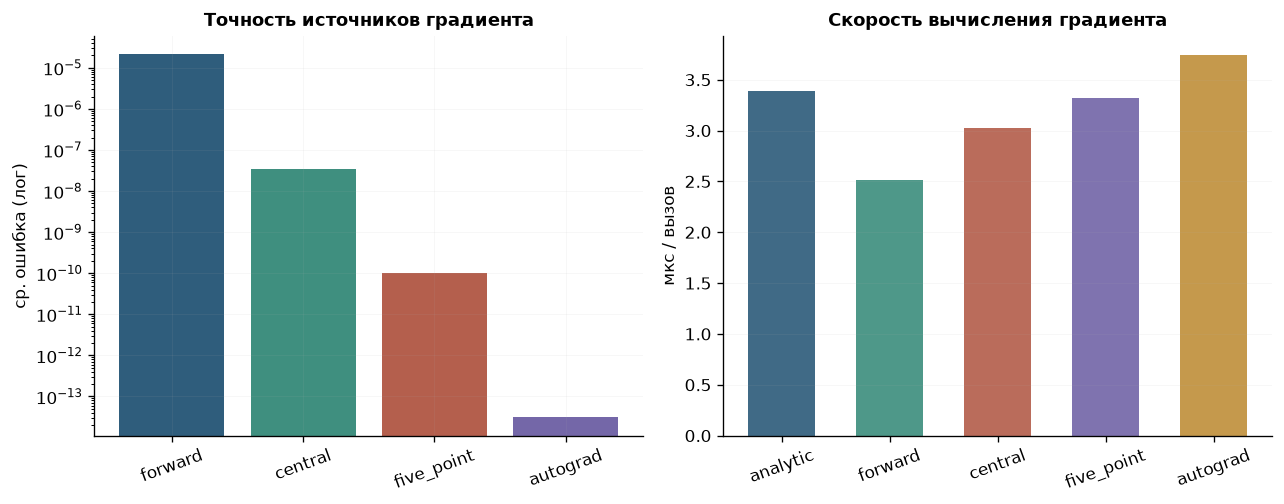

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.3))
order = ["forward", "central", "five_point", "autograd"]
err_vals = [diff_table.set_index("источник").loc[s, "ср. ошибка"] + 1e-18 for s in order]
axes[0].bar(order, err_vals, color=[plotting.PALETTE[i] for i in range(len(order))])
axes[0].set_yscale("log")
axes[0].set_ylabel("ср. ошибка (лог)")
axes[0].set_title("Точность источников градиента")
axes[0].tick_params(axis="x", rotation=20)

time_order = ["analytic", "forward", "central", "five_point", "autograd"]
time_vals = [diff_table.set_index("источник").loc[s, "мкс/вызов"] for s in time_order]
plotting.bar_comparison(
    axes[1],
    time_order,
    time_vals,
    ylabel="мкс / вызов",
    title="Скорость вычисления градиента",
    highlight_max=False,
)
axes[1].tick_params(axis="x", rotation=20)
plt.show()

**Вывод.** `Dual` почти совпадает с аналитикой. Численные схемы универсальны, но
дороже: они требуют нескольких вычислений функции на координату

## 6. Мини-бенчмарк против `scipy.optimize`

Сверяем Розенброк 2D с `scipy.optimize`: качество, итерации, вызовы функции и
время

In [9]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scipy_rows = []
    for method in ("CG", "BFGS", "L-BFGS-B", "Nelder-Mead", "Powell"):
        row = experiments.scipy_minimize(rosen2d, x0, method=method, max_iter=20000)
        if row is not None:
            scipy_rows.append(row)

# Наши лучшие первого порядка для контекста.
optlib_rows = []
for name, res in first_results.items():
    row = experiments.result_summary(name, res, rosen2d)
    times = np.asarray(res["trajectory"].get("time_ms", []), dtype=float)
    row["wall_ms"] = float(times[-1]) if times.size else np.nan
    optlib_rows.append(row)

bench = pd.DataFrame(optlib_rows + scipy_rows)[
    ["method", "value", "iterations", "function_evaluations", "wall_ms", "converged"]
]
bench.columns = ["метод", "f*", "итераций", "вызовов f", "время, мс", "сошёлся"]
bench.round(10)

,метод,f*,итераций,вызовов f,"время, мс",сошёлся
0,gradient_descent,1.94e-08,20000,20001,2.0938,False
1,heavy_ball,1e-10,2472,2473,0.2711,True
2,nesterov,1e-10,2516,2517,0.2569,True
3,adam,1e-10,5147,5148,0.9966,True
4,scipy:CG,0,36,78,7.8001,True
5,scipy:BFGS,0,32,39,3.8924,True
6,scipy:L-BFGS-B,0,36,44,7.4807,True
7,scipy:Nelder-Mead,8e-10,85,159,7.0187,True
8,scipy:Powell,0,23,607,12.1526,True


**Вывод.** `optlib` достигает $f^* \to 0$. По итерациям first-order методы
уступают BFGS/CG из `scipy`, что ожидаемо без информации о кривизне

## Выводы

1. Конечные разности дают ожидаемые порядки $O(h)$, $O(h^2)$, $O(h^4)$; нужен
   оптимальный $h^*$
2. `Dual`-autograd даёт машинную точность за один проход
3. GD, Heavy Ball, Nesterov и Adam сходятся на 2D/ND Розенброке; инерция и Adam
   заметно быстрее GD
4. Качество совпадает с `scipy`; отставание по итерациям объясняется отсутствием
   кривизны у методов первого порядка